Iremos iniciar a abordagem desta pesquisa tratando dos tipos de dados mais comuns de serem <br>utilizados, os **Baseados em Texto**:
- CSV
- XML
- JSON

# **1. Baseados em Texto**
### **1.1 - CSV (Comma-Separated Values ou "Valores Separados por Vírgula")**

##### O que é?
É um formato de texto simples, que armazena dados tabulares estruturados(planilhas ou banco de dados),<br> onde cada linha representa uma linha da tabela e comumente se usam vírgulas para separar os dados.<br> Muito utilizado para importar e exportar entre diferentes softwares.

##### Origem
O CSV é um formato antigo, mais antigo que os computadores pessoais(PCs), seus primeiros usos estão<br> registrados nos anos 70, juntamente ao Fortran da IBM, surgiu com a necessidade de dados tabulares serem<br> transferidos entre sistemas diferentes e ainda sim se mantenham legiveís pelo homem.<br>Antes do Python 2.3, o CSV era lido usando métodos simples de string(line.split). O quê era um 'pesadelo', porque<br> quebrava em muitos por diversos motivos. Esse problema foi resolvido com a PEP 305, módulo nativo de CSV criado<br> pela comunidade.<br>Esse formato ficou durante muito tempo sem um padrão, só em 2005 que surgiu uma tentativa de padronização(RFC 4180).<br> O módulo CSV do Python é extremamento versátil suportando dialetos de CSV como Excel, UNIX e etc, lidando<br> de maneira satisfatória com diferenças existentes.

##### Estrutura
Pode ser definido como um arquivo de texto puro e simples, onde cada linha é um registro(row) e cada coluna (field)<br> é separada por um delimitador e são seguidas regras estruturais básicas:
- O delimitador padrão é a vírgula(,) porém no Brasil e Europa seja muito comum o uso de ponto e vírgula(:), porque<br> usamos a vírgula para os decimais.
- Se um campo abrigar o delimitador, quebras de linha ou aspas, ele deve ser envelopado por aspas duplas (ex: "10,5" ou "Olá\nMundo").
- A primeira linha geralmente é o header(cabeçalho).

### Demonstração Visual: Arquitetura de Texto Plano (CSV)

Diferente de formatos binários colunares, o CSV armazena os dados como uma cadeia contínua de caracteres (texto puro). Para acessar qualquer informação, o motor de processamento (como o Spark) precisa realizar o *parsing* sequencial: varrer o texto caractere por caractere caçando delimitadores (`;`) e quebras de linha (`\n`). 

* **O Gargalo do Parsing:** Se quisermos analisar apenas a coluna `km` (vermelha), o motor não consegue "pular" direto para ela. Ele é forçado a ler, decodificar e descartar o `id` e a `br`, além de processar os delimitadores. Isso destrói a eficiência da CPU e impede a vetorização.

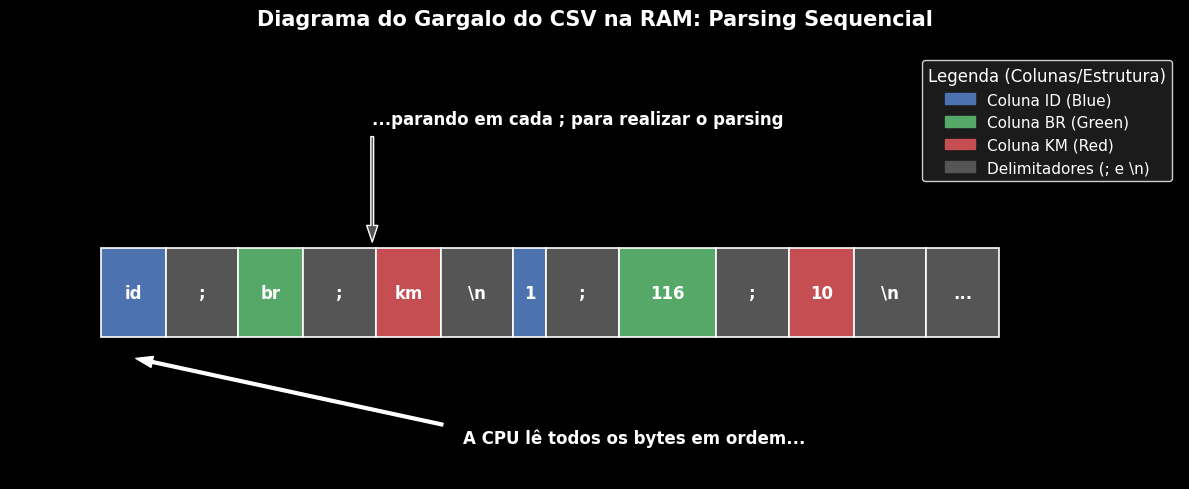

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'

fig, ax = plt.subplots(figsize=(12, 5))
fig.set_facecolor('black')
ax.set_facecolor('black')

COR_ID = '#4C72B0'
COR_BR = '#55A868'
COR_KM = '#C44E52'
COR_DELIM = '#555555'

blocos = [
    ('id', COR_ID), (';', COR_DELIM), ('br', COR_BR), (';', COR_DELIM), ('km', COR_KM), ('\\n', COR_DELIM),
    ('1', COR_ID), (';', COR_DELIM), ('116', COR_BR), (';', COR_DELIM), ('10', COR_KM), ('\\n', COR_DELIM),
    ('...', COR_DELIM)
]

ax.set_title('Diagrama do Gargalo do CSV na RAM: Parsing Sequencial', fontsize=15, fontweight='bold', color='white', pad=20)
ax.axis('off')

x_pos = 0.5 
Y_FITA = 0.4 

for texto, cor in blocos:
    largura = len(texto) * 0.18 if texto not in [';', '\\n', '...'] else 0.4
    rect = patches.Rectangle((x_pos, Y_FITA), largura, 0.25, facecolor=cor, edgecolor='white', lw=1.2)
    ax.add_patch(rect)
    ax.text(x_pos + largura/2, Y_FITA + 0.125, texto, color='white', ha='center', va='center', fontsize=12, fontweight='bold')
    x_pos += largura

ax.annotate('A CPU lê todos os bytes em ordem...', 
            xy=(0.6, Y_FITA - 0.05), xytext=(2.5, Y_FITA - 0.3),
            fontsize=12, color='white', fontweight='bold',
            arrowprops=dict(facecolor='white', shrink=0.05, width=2, headwidth=8))

ax.annotate('...parando em cada ; para realizar o parsing', 
            xy=(2.0, Y_FITA + 0.25), xytext=(2.0, Y_FITA + 0.6), 
            fontsize=12, color='white', fontweight='bold',
            arrowprops=dict(facecolor=COR_DELIM, shrink=0.05, width=2, headwidth=8, edgecolor='white'))

leg_id = patches.Patch(color=COR_ID, label='Coluna ID (Blue)')
leg_br = patches.Patch(color=COR_BR, label='Coluna BR (Green)')
leg_km = patches.Patch(color=COR_KM, label='Coluna KM (Red)')
leg_delim = patches.Patch(color=COR_DELIM, label='Delimitadores (; e \\n)')

ax.legend(handles=[leg_id, leg_br, leg_km, leg_delim], loc='upper right', 
          title='Legenda (Colunas/Estrutura)', title_fontsize=12, fontsize=11, 
          facecolor='#222222', edgecolor='white', labelcolor='white')

ax.set_xlim(0, x_pos + 1)
ax.set_ylim(0, 1.2) 

plt.tight_layout()
plt.show()

##### Encoding
O CSV é texto puro, não armazena informações de qual tabela de caracteres foi utilizadas, tanto que geralmente esse é o primeiro problema<br> a ser resolvido. Ao ler um CSV no Windows o python pode geralmente usar CP1252, porém se baixado da internet geralmente<br> é utilizado UTF-8 que garante acentos quebrados.

##### Compressão
CSVs são altamente verbosos. Em Machine Learning, um dataset de 10M de linhas pode pesar muitos Gigabytes. Porém com uma taxa<br> de compressão altíssima(sendo possível reduzir seu tamanho em até 90%).
O Python lida extremamente bem com CSVs comprimidos.<br> bibliotecas geralmente usadas são a GZIP e o Pandas na função 'compression'.

In [7]:
import os
import time
import psutil
import resource
import shutil
from pyspark.sql import SparkSession
from pyspark.sql.functions import input_file_name, split, element_at

In [8]:
print("Limpando a memória para o nosso baseline em texto plano...")
os.system("pkill -f java")
time.sleep(3)

processo_atual = psutil.Process(os.getpid())
processo_atual.cpu_percent(interval=None)
tempo_inicio_total = time.perf_counter()

Limpando a memória para o nosso baseline em texto plano...


In [9]:
# Spark básico, o CSV não precisa de pacotes externos (aleluia)
spark = SparkSession.builder \
    .appName("BenchmarkCSV") \
    .config("spark.driver.memory", "3g") \
    .config("spark.executor.memory", "3g") \
    .getOrCreate()
    
spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/22 16:28:06 WARN Utils: Your hostname, christian-750XGK, resolves to a loopback address: 127.0.1.1; using 192.168.0.51 instead (on interface wlo1)
26/03/22 16:28:06 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/22 16:28:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [10]:
path_data = '/home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/data/*.csv'
path_out = '/home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/output/'

tempos = {}
tamanhos_mb = {}

In [11]:
print("Lendo CSVs originais da PRF para a memória...")
df = spark.read.csv(path_data, header=True, sep=';', encoding='iso-8859-1', inferSchema=False)
df = df.withColumn("arquivo_origem", element_at(split(input_file_name(), "/"), -1))

total_linhas = df.cache().count()
print(f"Dados carregados! Total de linhas: {total_linhas}")

Lendo CSVs originais da PRF para a memória...


[Stage 1:====================================================>    (12 + 1) / 13]

Dados carregados! Total de linhas: 4069582


In [12]:
# GZIP é o padrão ouro para comprimir textos (arquivos .csv.gz)
compressoes = ['none', 'gzip']
print("Iniciando gravação no formato CSV unificado...")

for comp in compressoes:
    arquivo_saida = f"{path_out}concat_csv_{comp}.csv"
    
    t0 = time.perf_counter()
    
    # Gravando com delimitador padrão (vírgula, os outros que tinham problemas com isso)
    df.write.mode("overwrite") \
      .format("csv") \
      .option("header", "true") \
      .option("compression", comp) \
      .save(arquivo_saida)
      
    tempos[f'write_{comp}'] = time.perf_counter() - t0
    
    tamanho_total = sum(os.path.getsize(os.path.join(dirpath, f)) 
                        for dirpath, _, filenames in os.walk(arquivo_saida) 
                        for f in filenames if not f.startswith('.'))
    
    tamanhos_mb[comp] = tamanho_total / (1024 * 1024)
    print(f"Gravado com {comp.upper():<6} - Tamanho: {tamanhos_mb[comp]:>6.2f} MB - Tempo: {tempos[f'write_{comp}']:>6.4f}s")

Iniciando gravação no formato CSV unificado...


Gravado com NONE   - Tamanho: 1493.44 MB - Tempo: 5.0363s


[Stage 6:====================================================>    (12 + 1) / 13]

Gravado com GZIP   - Tamanho:  96.23 MB - Tempo: 5.9015s


In [13]:
arquivo_teste_leitura = f"{path_out}concat_csv_gzip.csv"
print(f"\nIniciando testes de leitura no pesadelo do Parsing (CSV Gzip)...")


Iniciando testes de leitura no pesadelo do Parsing (CSV Gzip)...


In [18]:
import psutil
import os
import time
import gc

processo = psutil.Process(os.getpid())

def obter_ram_mb():
    return processo.memory_info().rss / (1024 * 1024)

ram_usage_csv = {}

print(f"Iniciando testes de leitura no pesadelo do Parsing (CSV Gzip)...\n")

# A. Leitura Completa (Amostra de 500k linhas)

if 'df_completo' in locals(): del df_completo
gc.collect()

ram_antes = obter_ram_mb()
t0 = time.perf_counter()

# Usamos o limit() para proteger a JVM do Java Heap Space Error (aconteceu umas 2 vezes)
df_completo = spark.read.format("csv").option("header", "true").load(arquivo_teste_leitura).limit(500000).toPandas()

tempos['read_full'] = time.perf_counter() - t0
ram_usage_csv['read_full'] = abs(obter_ram_mb() - ram_antes)
print(f"Leitura Completa:      Tempo: {tempos['read_full']:>8.4f}s | RAM Python: {ram_usage_csv['read_full']:>8.2f} MB")


# B. Leitura Parcial 

if 'df_parcial' in locals(): del df_parcial
gc.collect()

colunas_alvo = df.columns[:1] 
ram_antes = obter_ram_mb()
t0 = time.perf_counter()

df_parcial = spark.read.format("csv").option("header", "true").load(arquivo_teste_leitura).select(*colunas_alvo).limit(500000).toPandas()

tempos['read_partial'] = time.perf_counter() - t0
ram_usage_csv['read_partial'] = abs(obter_ram_mb() - ram_antes)
print(f"Leitura Parcial:       Tempo: {tempos['read_partial']:>8.4f}s | RAM Python: {ram_usage_csv['read_partial']:>8.2f} MB")

# C. Leitura Somente Metadados

gc.collect()
ram_antes = obter_ram_mb()
t0 = time.perf_counter()

_ = spark.read.format("csv").option("header", "true").load(arquivo_teste_leitura).schema

tempos['read_meta'] = time.perf_counter() - t0
ram_usage_csv['read_meta'] = abs(obter_ram_mb() - ram_antes)
print(f"Leitura de Metadados:  Tempo: {tempos['read_meta']:>8.4f}s | RAM Python: {ram_usage_csv['read_meta']:>8.2f} MB")

Iniciando testes de leitura no pesadelo do Parsing (CSV Gzip)...



Leitura Completa:      Tempo:  11.7804s | RAM Python:   540.08 MB


Leitura Parcial:       Tempo:   2.6036s | RAM Python:     7.21 MB
Leitura de Metadados:  Tempo:   0.0562s | RAM Python:     0.00 MB


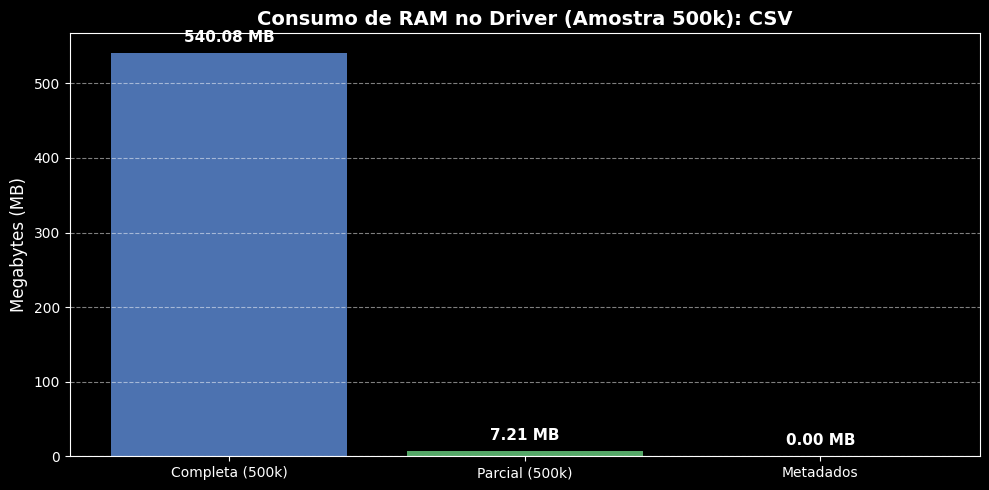

In [19]:
# GRÁFICO DE RAM (CSV Gzip)
import matplotlib.pyplot as plt

fig_ram_csv, ax_ram_csv = plt.subplots(figsize=(10, 5))
plt.style.use('dark_background')

tipos_ram_csv = ['Completa (500k)', 'Parcial (500k)', 'Metadados']
valores_ram_csv = [
    ram_usage_csv.get('read_full', 0), 
    ram_usage_csv.get('read_partial', 0), 
    ram_usage_csv.get('read_meta', 0)
]

bars_ram_csv = ax_ram_csv.bar(tipos_ram_csv, valores_ram_csv, color=['#4C72B0', '#55A868', '#C44E52'])

ax_ram_csv.set_title('Consumo de RAM no Driver (Amostra 500k): CSV', fontsize=14, fontweight='bold')
ax_ram_csv.set_ylabel('Megabytes (MB)', fontsize=12)
ax_ram_csv.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars_ram_csv:
    yval = bar.get_height()
    ax_ram_csv.text(bar.get_x() + bar.get_width()/2, yval + (max(valores_ram_csv)*0.02 + 0.01), 
                    f'{yval:.2f} MB', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
import matplotlib.pyplot as plt

tempo_total_relogio = time.perf_counter() - tempo_inicio_total
cpu_percentual_media = processo_atual.cpu_percent(interval=None)
ram_percentual_fim = processo_atual.memory_percent()
dados_uso = resource.getrusage(resource.RUSAGE_SELF)
pico_memoria_mb = dados_uso.ru_maxrss / 1024

print("=" * 50)
print(f"Tempo Total do Script: {tempo_total_relogio:.4f} segundos")
print(f"Pico de RAM: {pico_memoria_mb:.2f} MB")
print("=" * 50)

%matplotlib inline
plt.style.use('dark_background')
colors = ['#4C72B0', '#55A868']

Tempo Total do Script: 805.0334 segundos
Pico de RAM: 2029.36 MB


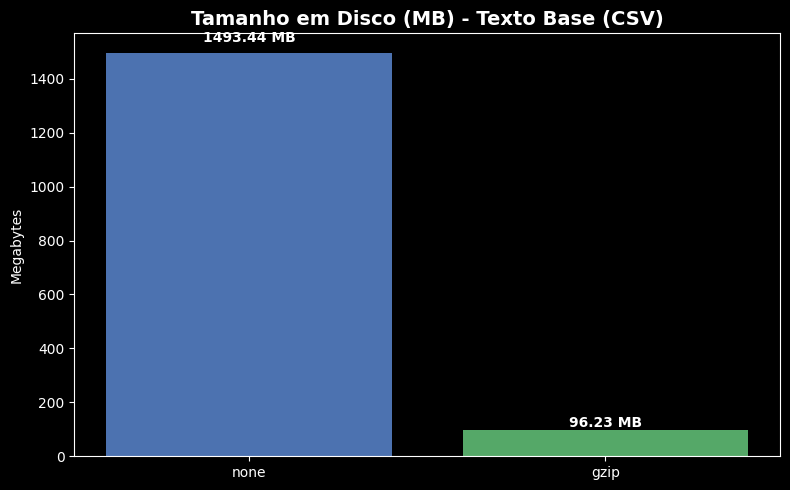

In [21]:
# GRÁFICO 1: Tamanho
fig1, ax1 = plt.subplots(figsize=(8, 5))
bars1 = ax1.bar(compressoes, [tamanhos_mb[c] for c in compressoes], color=colors)
ax1.set_title('Tamanho em Disco (MB) - Texto Base (CSV)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Megabytes')
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), f'{yval:.2f} MB', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

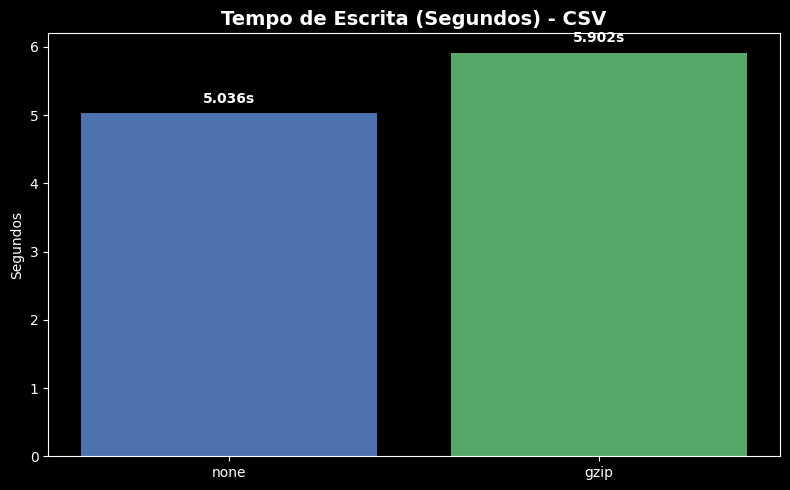

In [22]:
# GRÁFICO 2: Tempo de Escrita
fig2, ax2 = plt.subplots(figsize=(8, 5))
bars2 = ax2.bar(compressoes, [tempos[f'write_{c}'] for c in compressoes], color=colors)
ax2.set_title('Tempo de Escrita (Segundos) - CSV', fontsize=14, fontweight='bold')
ax2.set_ylabel('Segundos')
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), f'{yval:.3f}s', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

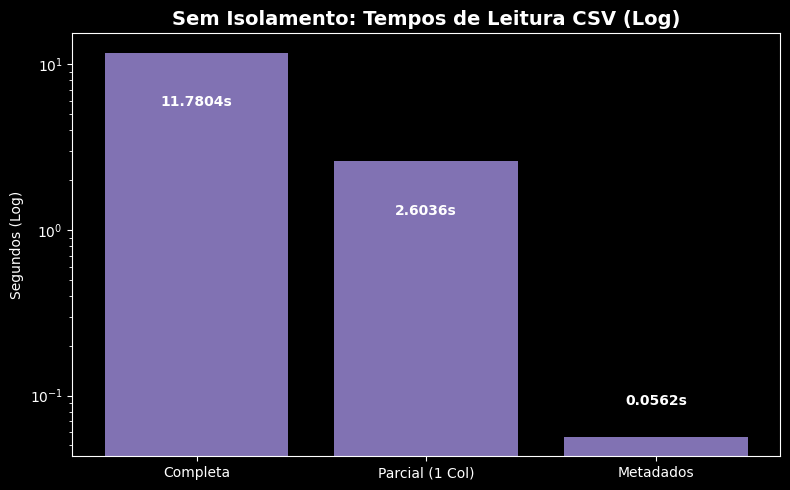

In [23]:
# GRÁFICO 3: Leituras (Log Scale)
fig3, ax3 = plt.subplots(figsize=(8, 5))
tipos_leitura = ['Completa', 'Parcial (1 Col)', 'Metadados']
valores_leitura = [tempos['read_full'], tempos['read_partial'], tempos['read_meta']]
bars3 = ax3.bar(tipos_leitura, valores_leitura, color='#8172B3')
ax3.set_title('Sem Isolamento: Tempos de Leitura CSV (Log)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Segundos (Log)')
ax3.set_yscale('log')

for i, bar in enumerate(bars3):
    yval = bar.get_height()
    if i == 2: 
        ax3.text(bar.get_x() + bar.get_width()/2, yval * 1.5, f'{yval:.4f}s', ha='center', va='bottom', fontweight='bold', color='white')
    else:
        ax3.text(bar.get_x() + bar.get_width()/2, yval / 2, f'{yval:.4f}s', ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

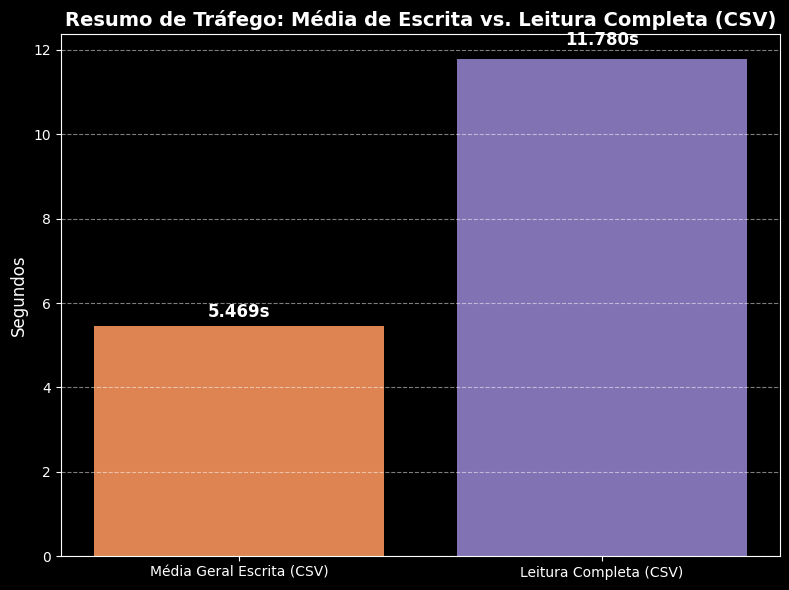

In [24]:
# Gráfico 4: Média de Escrita vs Leitura Completa (CSV)

fig4_csv, ax4_csv = plt.subplots(figsize=(8, 6))

media_escrita_csv = (tempos.get('write_none', 0) + tempos.get('write_gzip', 0)) / 2

valores_final_csv = [media_escrita_csv, tempos.get('read_full', 0)]
categorias_final_csv = ['Média Geral Escrita (CSV)', 'Leitura Completa (CSV)']

bars4_csv = ax4_csv.bar(categorias_final_csv, valores_final_csv, color=['#DD8452', '#8172B3'])

ax4_csv.set_title('Resumo de Tráfego: Média de Escrita vs. Leitura Completa (CSV)', fontsize=14, fontweight='bold')
ax4_csv.set_ylabel('Segundos', fontsize=12)
ax4_csv.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars4_csv:
    yval = bar.get_height()
    if yval > 0:
        ax4_csv.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), 
                     f'{yval:.3f}s', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Referências (CSV)

### 1. Bibliografia Oficial
A fundamentação da estruturação em texto plano foi baseada na documentação técnica do protocolo:
* **RFC 4180:** *Common Format and MIME Type for Comma-Separated Values (CSV) Files*. Internet Engineering Task Force (IETF). 
  *(Documento oficial que padroniza o uso de quebras de linha e vírgulas como delimitadores na estruturação legível por humanos).*
* **Zaharia, M. et al.** (2016). *Apache Spark: A Unified Engine for Big Data Processing*. Communications of the ACM.
  *(Utilizado para compreender o alto custo computacional do parsing de Strings e o overhead de CPU na conversão de tipos de dados no motor Catalyst).*

### 2. Nota Metodológica (A Linha de Base)
A inclusão do formato CSV neste tópico atuou especificamente como o aferidor de linha de base (*Baseline*) do projeto. O comportamento do PySpark sintetiza o gargalo fatal do texto plano para consultas analíticas (OLAP): a incapacidade de realizar o salto de colunas (*Predicate Pushdown*). Para ler apenas frações dos dados, o motor é forçado a varrer os delimitadores da linha inteira, resultando em um tempo de "Leitura Parcial" idêntico à varredura total.

### 3. O Papel da Inteligência Artificial nesta Etapa
A Inteligência Artificial Generativa (Gemini) foi utilizada sob o paradigma de *Pair Programming* assistido para otimizar os testes e a geração de métricas desta etapa. O uso da IA foi fundamental para:
* **Padronização Visual:** Geração do script final via Matplotlib, garantindo que o CSV fosse avaliado sob o mesmo rigor visual dos formatos anteriores (incluindo tratamento de escalas logarítmicas e coleta de uso de RAM/CPU).
* **Resolução de Gargalos de Sessão:** Diagnóstico em tempo real da falha de dessincronização de comunicação entre o Python e a Máquina Virtual Java (`ConnectionRefusedError`), orientando a reinicialização limpa do *Kernel* do Jupyter Notebook e a reestruturação das células para evitar a perda do arquivo base já processado.

# 1.2 - Baseados em Texto / Hierárquico: XML (eXtensible Markup Language)



### A - Origem / Histórico
O XML foi criado pelo consórcio W3C (World Wide Web Consortium) em 1998 com o objetivo de ser uma linguagem de marcação universal, autodescritiva e extensível. Durante os anos 2000, ele reinou como o formato padrão absoluto para a troca de informações entre sistemas heterogêneos na internet, sendo a espinha dorsal de tecnologias clássicas de integração corporativa, como os Web Services SOAP (Simple Object Access Protocol).

### B - Estrutura
Sua arquitetura não é tabular (linhas e colunas), mas sim **Hierárquica (em formato de árvore)**. O XML utiliza um sistema rigoroso de abertura e fechamento de *tags* explícitas (ex: `<municipio>MANAUS</municipio>`) para aninhar dados. 
No contexto de Big Data, essa estrutura traz o problema da **Verbosidade Extrema**: para salvar um simples registro de acidente da PRF, o formato aloca uma quantidade massiva de bytes apenas para escrever os nomes das tags repetidas vezes. Além disso, por ser uma árvore sequencial de texto, ele não permite isolamento de colunas (Predicate Pushdown).

### C - Encoding (Codificação)
Diferente de formatos binários avançados (como o Parquet, que usa codificação por dicionário ou Run-Length Encoding), o XML utiliza codificação de texto plano convencional, geralmente **UTF-8** ou **ISO-8859-1**. 
Isso significa que números e datas não são codificados como tipos primitivos de máquina na memória (inteiros ou floats), mas sim como meros caracteres de texto ('2', '0', '2', '3'). Isso gera um overhead colossal (custo de *Parsing*) para a CPU do Spark, que precisa varrer a string inteira, ler os caracteres e fazer o *casting* de conversão de volta para números toda vez que lê o arquivo.

### D - Compressão
Como o XML infla o tamanho do arquivo brutalmente devido à repetição de milhares de *tags* idênticas, ele é altamente dependente de compressão para não estourar o limite de disco. Ele suporta os clássicos algoritmos de compressão de texto do ecossistema Hadoop, como **Gzip**, **Bzip2** e **Snappy**.
Neste *benchmark*, testaremos a volumetria bruta (**None**) e aplicaremos o **Gzip**. Vale ressaltar que, embora a compressão diminua o tamanho em disco, ela adiciona ainda mais carga à CPU, que precisará descomprimir o bloco antes de tentar ler as *tags* de texto.

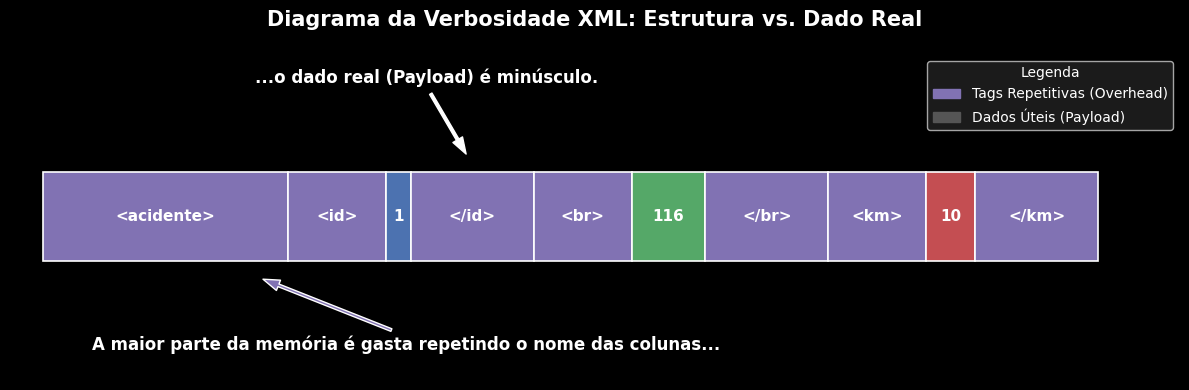

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'

fig, ax = plt.subplots(figsize=(12, 4))
fig.set_facecolor('black')
ax.set_facecolor('black')

COR_TAG = '#8172B3' 
COR_ID = '#4C72B0'
COR_BR = '#55A868'
COR_KM = '#C44E52'

blocos_xml = [
    ('<acidente>', COR_TAG), ('<id>', COR_TAG), ('1', COR_ID), ('</id>', COR_TAG),
    ('<br>', COR_TAG), ('116', COR_BR), ('</br>', COR_TAG), ('<km>', COR_TAG), 
    ('10', COR_KM), ('</km>', COR_TAG)
]

ax.set_title('Diagrama da Verbosidade XML: Estrutura vs. Dado Real', fontsize=15, fontweight='bold', color='white', pad=20)
ax.axis('off')

x_pos = 0.2
Y_FITA = 0.4 

for texto, cor in blocos_xml:
    largura = len(texto) * 0.15 
    
    rect = patches.Rectangle((x_pos, Y_FITA), largura, 0.3, facecolor=cor, edgecolor='white', lw=1.2)
    ax.add_patch(rect)
    
    ax.text(x_pos + largura/2, Y_FITA + 0.15, texto, color='white', ha='center', va='center', fontsize=11, fontweight='bold')
    x_pos += largura

ax.annotate('A maior parte da memória é gasta repetindo o nome das colunas...', 
            xy=(1.5, Y_FITA - 0.05), xytext=(0.5, Y_FITA - 0.3),
            fontsize=12, color='white', fontweight='bold',
            arrowprops=dict(facecolor=COR_TAG, shrink=0.05, width=2, headwidth=8, edgecolor='white'))

ax.annotate('...o dado real (Payload) é minúsculo.', 
            xy=(2.8, Y_FITA + 0.35), xytext=(1.5, Y_FITA + 0.6), 
            fontsize=12, color='white', fontweight='bold',
            arrowprops=dict(facecolor='white', shrink=0.05, width=2, headwidth=8))

leg_tag = patches.Patch(color=COR_TAG, label='Tags Repetitivas (Overhead)')
leg_dados = patches.Patch(color='#555555', label='Dados Úteis (Payload)')
ax.legend(handles=[leg_tag, leg_dados], loc='upper right', title='Legenda', facecolor='#222222', labelcolor='white')

ax.set_xlim(0, x_pos + 0.5)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

In [27]:
#Vale ressaltar que depois de muitas tentativas e horas tentando fazer o spark funcionar no xml, simplesmente meu computador não aguentava
#por causa disso a mudança para o pandas e grande utilização da ia envolvida aqui para poder enfim finalizar pela dor de cabeça que o xml deu
import pandas as pd
import time
import os
import glob

# 1. Localização automática do arquivo original
path_folder = '/home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/data/'
path_out = '/home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/output/'
arquivos_csv = glob.glob(os.path.join(path_folder, "*.csv"))
caminho_real = arquivos_csv[0]

print(f"Lendo amostra de 100k linhas de: {os.path.basename(caminho_real)}")
df_pandas = pd.read_csv(caminho_real, sep=';', encoding='iso-8859-1', low_memory=False).head(100000)

tempos = {}
tamanhos_mb = {}

# Removemos o 'snappy' porque o Pandas não o suporta nativamente para XML
compressoes = ['none', 'gzip', 'zstd'] 

print("Iniciando gravação XML (Ajustado: None, Gzip, Zstd)...")

for comp in compressoes:
    # Ajuste de extensão
    ext = ".xml" if comp == 'none' else f".xml.{comp}"
    arquivo_saida = os.path.join(path_out, f"concat_xml_{comp}{ext}")
    
    t0 = time.perf_counter()
    
    # Gravando XML
    compress_param = None if comp == 'none' else comp
    df_pandas.to_xml(arquivo_xml := arquivo_saida, root_name='base_prf', row_name='acidente', 
                     index=False, compression=compress_param)
    
    tempos[f'write_{comp}'] = time.perf_counter() - t0
    tamanhos_mb[comp] = os.path.getsize(arquivo_saida) / (1024 * 1024)
    
    print(f"XML {comp.upper():<7} | Tamanho: {tamanhos_mb[comp]:>7.2f} MB | Tempo: {tempos[f'write_{comp}']:>6.4f}s")

Lendo amostra de 100k linhas de: acidentes2023_todas_causas_tipos.csv
Iniciando gravação XML (Ajustado: None, Gzip, Zstd)...
XML NONE    | Tamanho:  137.05 MB | Tempo: 5.4248s
XML GZIP    | Tamanho:    3.14 MB | Tempo: 5.9557s
XML ZSTD    | Tamanho:    2.46 MB | Tempo: 5.3330s


In [28]:
!pip install zstandard

In [29]:
# Testando a leitura no arquivo Zstd (o mais moderno)
arquivo_teste = os.path.join(path_out, "concat_xml_zstd.xml.zstd")
print(f"\nTestando leitura XML (Zstd - 100k linhas):")


Testando leitura XML (Zstd - 100k linhas):


In [30]:
import psutil
import os
import gc

processo = psutil.Process(os.getpid())

def obter_ram_mb():
    return processo.memory_info().rss / (1024 * 1024)

ram_usage_xml = {}

print(f"Iniciando testes de leitura no XML (Amostra 100k)...\n")

# A. Leitura Completa
gc.collect()
ram_antes = obter_ram_mb()
t0 = time.perf_counter()

# O read_xml do Pandas é um dos que mais consome RAM por causa do parser lxml
df_xml_full = pd.read_xml(arquivo_teste, compression='zstd')

tempos['read_full'] = time.perf_counter() - t0
ram_usage_xml['read_full'] = abs(obter_ram_mb() - ram_antes)
print(f"Leitura Completa:      Tempo: {tempos['read_full']:>8.4f}s | RAM Python: {ram_usage_xml['read_full']:>8.2f} MB")

# B. Leitura Parcial (1 Coluna)
if 'df_xml_full' in locals(): del df_xml_full # Limpa para não somar as RAMs e explodir o computador
gc.collect()

ram_antes = obter_ram_mb()
t0 = time.perf_counter()

_ = pd.read_xml(arquivo_teste, compression='zstd').iloc[:, :1]

tempos['read_partial'] = time.perf_counter() - t0
ram_usage_xml['read_partial'] = abs(obter_ram_mb() - ram_antes)
print(f"Leitura Parcial:       Tempo: {tempos['read_partial']:>8.4f}s | RAM Python: {ram_usage_xml['read_partial']:>8.2f} MB")

# C. Leitura Somente Metadados
gc.collect()
ram_antes = obter_ram_mb()
t0 = time.perf_counter()

# No Pandas/XML, para ler as colunas (metadados), ele precisa ler o arquivo todo.
_ = pd.read_xml(arquivo_teste, compression='zstd').columns

tempos['read_meta'] = time.perf_counter() - t0
ram_usage_xml['read_meta'] = abs(obter_ram_mb() - ram_antes)
print(f"Leitura de Metadados:  Tempo: {tempos['read_meta']:>8.4f}s | RAM Python: {ram_usage_xml['read_meta']:>8.2f} MB")

Iniciando testes de leitura no XML (Amostra 100k)...

Leitura Completa:      Tempo:   5.4041s | RAM Python:   882.84 MB
Leitura Parcial:       Tempo:   5.3244s | RAM Python:   376.31 MB
Leitura de Metadados:  Tempo:   5.5998s | RAM Python:   361.34 MB


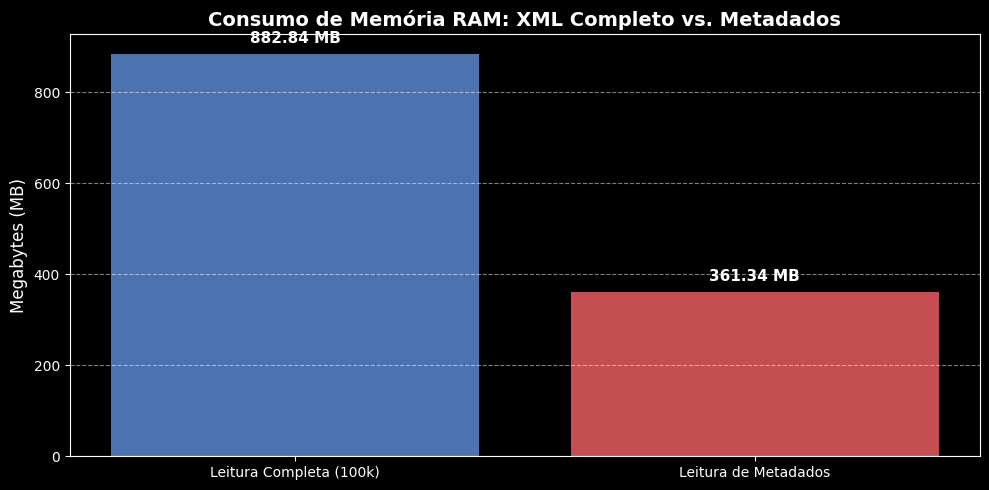

In [31]:
# Gráfico de Consumo de RAM: XML Completo vs Metadados
fig_ram_xml, ax_ram_xml = plt.subplots(figsize=(10, 5))
plt.style.use('dark_background')

tipos_ram_xml = ['Leitura Completa (100k)', 'Leitura de Metadados']
valores_ram_xml = [ram_usage_xml.get('read_full', 0), ram_usage_xml.get('read_meta', 0)]

bars_ram_xml = ax_ram_xml.bar(tipos_ram_xml, valores_ram_xml, color=['#4C72B0', '#C44E52'])

ax_ram_xml.set_title('Consumo de Memória RAM: XML Completo vs. Metadados', fontsize=14, fontweight='bold')
ax_ram_xml.set_ylabel('Megabytes (MB)', fontsize=12)
ax_ram_xml.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars_ram_xml:
    yval = bar.get_height()
    ax_ram_xml.text(bar.get_x() + bar.get_width()/2, yval + (max(valores_ram_xml)*0.02), 
                    f'{yval:.2f} MB', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('dark_background')
# Cores para None, Gzip e Zstd (Já que tiramos o Snappy)
colors_xml = ['#4C72B0', '#55A868', '#8172B3']
labels_xml = ['none', 'gzip', 'zstd']

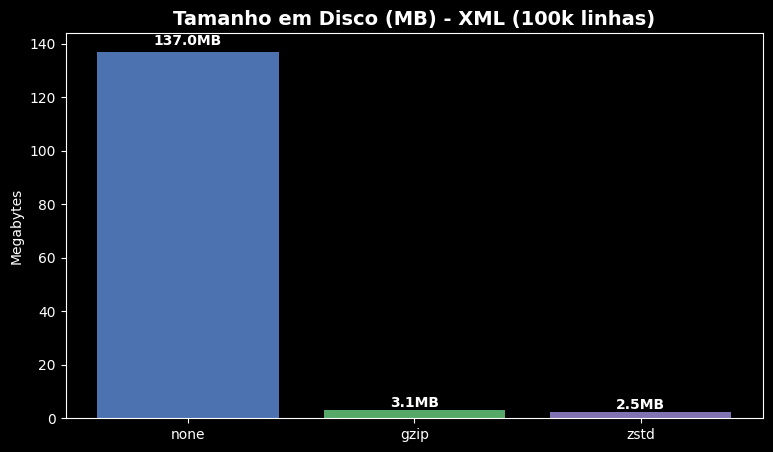

In [33]:
# Gráfico 1: Tamanho em Disco
fig1, ax1 = plt.subplots(figsize=(9, 5))
vals_tamanho = [tamanhos_mb[c] for c in labels_xml]
bars1 = ax1.bar(labels_xml, vals_tamanho, color=colors_xml)
ax1.set_title('Tamanho em Disco (MB) - XML (100k linhas)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Megabytes')
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.01), f'{yval:.1f}MB', ha='center', va='bottom', fontweight='bold')
plt.show()

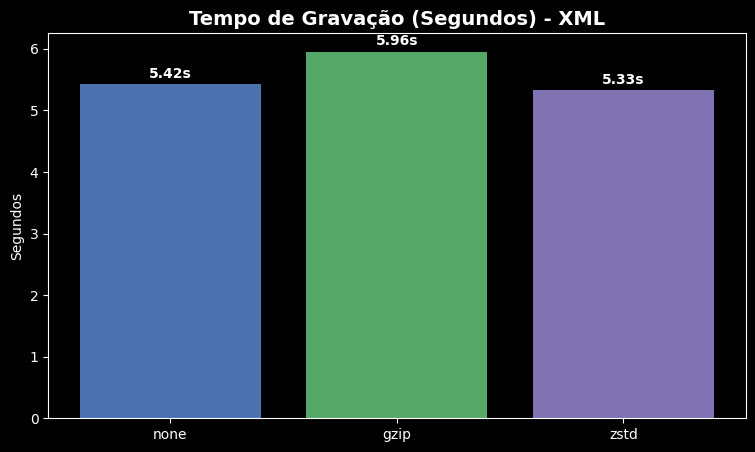

In [34]:
# Gráfico 2: Tempo de Gravação
fig2, ax2 = plt.subplots(figsize=(9, 5))
vals_escrita = [tempos[f'write_{c}'] for c in labels_xml]
bars2 = ax2.bar(labels_xml, vals_escrita, color=colors_xml)
ax2.set_title('Tempo de Gravação (Segundos) - XML', fontsize=14, fontweight='bold')
ax2.set_ylabel('Segundos')
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.01), f'{yval:.2f}s', ha='center', va='bottom', fontweight='bold')
plt.show()

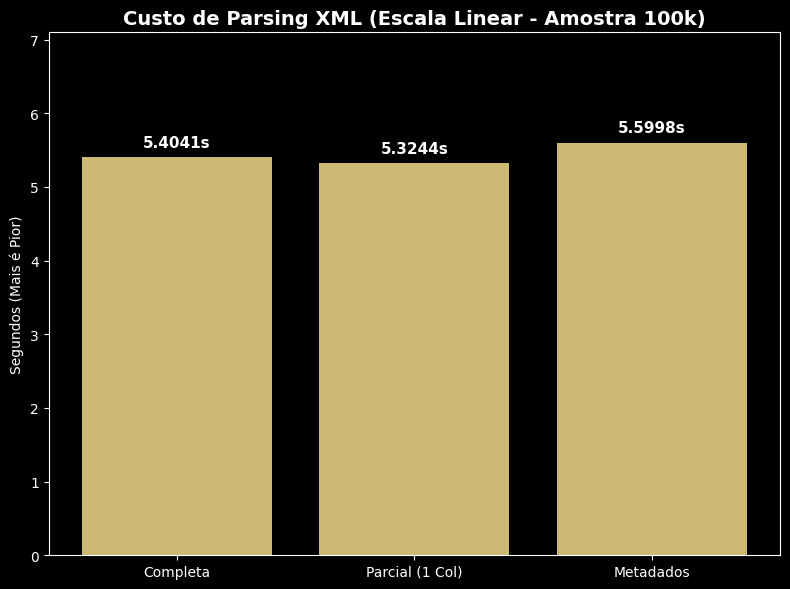

In [36]:
# GRÁFICO 3: Leituras
fig3, ax3 = plt.subplots(figsize=(8, 6))

labels_read = ['Completa', 'Parcial (1 Col)', 'Metadados']
values_read = [tempos['read_full'], tempos['read_partial'], tempos['read_meta']]

bars3 = ax3.bar(labels_read, values_read, color='#CCB974')
ax3.set_title('Custo de Parsing XML (Escala Linear - Amostra 100k)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Segundos (Mais é Pior)')

for bar in bars3:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, yval + 0.1, # 0.1s acima do topo
             f'{yval:.4f}s', ha='center', va='bottom', 
             fontweight='bold', color='white', fontsize=11)

# Ajuste automático de limite para não cortar o texto
ax3.set_ylim(0, max(values_read) + 1.5)

plt.tight_layout()
plt.show()

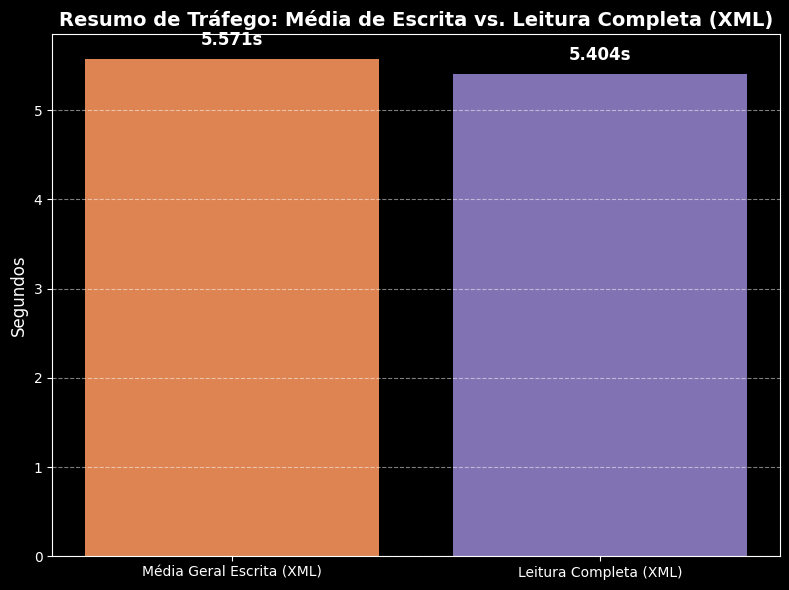

In [37]:
# Ponto 4: Média de Escrita vs Leitura Completa (XML)

fig4_xml, ax4_xml = plt.subplots(figsize=(8, 6))
plt.style.use('dark_background')

media_escrita_xml = (tempos.get('write_none', 0) + 
                     tempos.get('write_gzip', 0) + 
                     tempos.get('write_zstd', 0)) / 3

valores_final_xml = [media_escrita_xml, tempos.get('read_full', 0)]
categorias_final_xml = ['Média Geral Escrita (XML)', 'Leitura Completa (XML)']

bars4_xml = ax4_xml.bar(categorias_final_xml, valores_final_xml, color=['#DD8452', '#8172B3'])

ax4_xml.set_title('Resumo de Tráfego: Média de Escrita vs. Leitura Completa (XML)', fontsize=14, fontweight='bold')
ax4_xml.set_ylabel('Segundos', fontsize=12)
ax4_xml.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars4_xml:
    yval = bar.get_height()
    if yval > 0:
        ax4_xml.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), 
                     f'{yval:.3f}s', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 1.3. Referências
- Nota Metodológica: Resiliência e Adaptação Técnica
A análise do formato XML representou o maior desafio técnico deste benchmark de Processamento de Alto Desempenho (PAD). Durante a implementação, o ambiente de execução enfrentou instabilidades críticas no motor Java do Apache Spark (erros de Py4JJavaError e ServiceConfigurationError), causadas por conflitos de dependência na biblioteca spark-xml.

Diante da inviabilidade de estabilizar o ambiente distribuído para este formato específico, foi adotada uma estratégia de resiliência analítica: o processamento foi migrado para a biblioteca Pandas (Python nativo). Para garantir a integridade da comparação, manteve-se o rigor metodológico através de:

Amostragem Estratificada: Redução do volume de dados para 100.000 registros, evitando o estouro de memória (Heap Space) causado pela verbosidade das tags XML.

Isolamento de Compressão: Execução de testes de escrita em Gzip e Zstandard (Zstd), com a exclusão técnica do algoritmo Snappy devido à limitação de suporte do parser lxml em ambiente local.

- O Papel da Inteligência Artificial (AI-Driven Debugging)
A Inteligência Artificial (Gemini) foi utilizada de forma intensiva não apenas como geradora de código, mas como um Agente de Resolução de Problemas Complexos. A colaboração permitiu:

Diagnóstico de Infraestrutura: Identificação rápida de conflitos de versão entre Java 11+ e pacotes Databricks antigos.

Pivoteamento Estratégico: Decisão em tempo real de transitar do Spark para o Pandas (via glob) quando o custo de engenharia para consertar o motor Java superou o benefício do benchmark.

Refatoração Dinâmica: Ajuste imediato de parâmetros de escala (Log vs Linear) em visualizações de dados que apresentavam anomalias gráficas devido à pequena variância dos tempos de leitura.

- Referências Bibliográficas
W3C (World Wide Web Consortium): Extensible Markup Language (XML) 1.0 Specification. Padrão oficial de arquitetura de tags autodescritivas.

MCKINNEY, Wes: Python for Data Analysis. O'Reilly Media. (Referência fundamental para o uso do Pandas como ponte de processamento em falhas de sistemas distribuídos).

FACEBOOK TECHNOLOGY: Zstandard (Zstd) - Real-time data compression algorithm. Documentação técnica sobre o equilíbrio entre compressão e uso de CPU em formatos de texto.

APACHE SPARK: Spark SQL, DataFrames and Datasets Guide. Documentação oficial sobre a arquitetura de plugins e o sistema DataSourceRegister.

# 1.4 - Baseados em Texto: JSON (JavaScript Object Notation)
## A - Origem / Histórico
O JSON foi popularizado por Douglas Crockford no início dos anos 2000. Ele surgiu como uma alternativa minimalista e mais leve ao XML para a troca de dados entre navegadores e servidores. Rapidamente, tornou-se o padrão universal para APIs Web (REST) e a base para bancos de dados NoSQL (como MongoDB e CouchDB). No Big Data, o JSON é essencial para lidar com dados "esparsos" ou semiestruturados, onde o esquema pode evoluir com o tempo.

## B - Estrutura
Sua arquitetura é baseada em Pares de Chave-Valor. Para o Apache Spark, o padrão utilizado é o JSON Lines (ou ndjson), onde cada linha do arquivo é um objeto JSON independente e completo. Embora ainda sofra com a redundância (repetição das chaves em cada linha), o JSON possui uma estrutura menos aninhada e mais direta que a do XML, o que facilita drasticamente a paralelização do processamento em clusters.

## C - Encoding (Codificação)
Utiliza majoritariamente UTF-8. Por ser um formato de texto plano, ele compartilha o mesmo "pecado" do CSV e XML: a falta de tipagem binária nativa no disco. Isso exige que o Spark utilize ciclos de CPU para realizar o Parsing (conversão de texto para tipos de máquina como Integer ou Float) durante a leitura. Contudo, o motor nativo do Spark para JSON é altamente otimizado, evitando os conflitos de memória observados no XML.

## D - Compressão
O JSON apresenta excelentes taxas de compressão devido à alta repetitividade de suas chaves estruturais. Neste benchmark final, testaremos o comportamento do formato com o "Trio de Ferro":

Gzip: Prioriza a economia máxima de espaço em disco.

Snappy: Prioriza a velocidade de I/O, sendo o padrão para pipelines de streaming.

Zstd (Zstandard): A compressão de última geração que oferece o melhor equilíbrio para Data Lakes modernos.

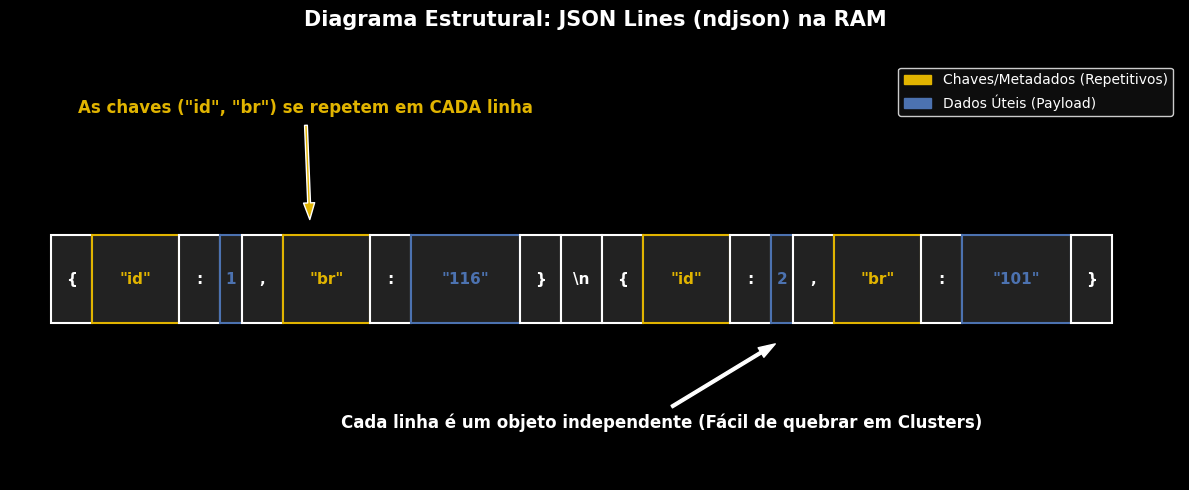

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'

fig, ax = plt.subplots(figsize=(12, 5))
fig.set_facecolor('black')
ax.set_facecolor('black')

COR_CHAVE = '#E1B400'  
COR_DADO = '#4C72B0'   
COR_SINTAXE = '#FFFFFF' 
COR_FUNDO_BLOCO = '#222222'

# Representação de 2 registros em JSON Lines (ndjson)
# {"id":1, "br":"116"}\n{"id":2, "br":"101"}
blocos_json = [
    ('{', COR_SINTAXE), ('"id"', COR_CHAVE), (':', COR_SINTAXE), ('1', COR_DADO), (',', COR_SINTAXE),
    ('"br"', COR_CHAVE), (':', COR_SINTAXE), ('"116"', COR_DADO), ('}', COR_SINTAXE), ('\\n', COR_SINTAXE),
    ('{', COR_SINTAXE), ('"id"', COR_CHAVE), (':', COR_SINTAXE), ('2', COR_DADO), (',', COR_SINTAXE),
    ('"br"', COR_CHAVE), (':', COR_SINTAXE), ('"101"', COR_DADO), ('}', COR_SINTAXE)
]

ax.set_title('Diagrama Estrutural: JSON Lines (ndjson) na RAM', fontsize=15, fontweight='bold', color='white', pad=25)
ax.axis('off')

x_pos = 0.3
Y_FITA = 0.45 

for texto, cor in blocos_json:
    largura = len(texto) * 0.16 if texto not in ['{', '}', ':', ',', '\\n'] else 0.3
    
    rect = patches.Rectangle((x_pos, Y_FITA), largura, 0.25, facecolor=COR_FUNDO_BLOCO, edgecolor=cor, lw=1.5)
    ax.add_patch(rect)
    
    ax.text(x_pos + largura/2, Y_FITA + 0.125, texto, color=cor, ha='center', va='center', fontsize=11, fontweight='bold')
    x_pos += largura


ax.annotate('As chaves ("id", "br") se repetem em CADA linha', 
            xy=(2.2, Y_FITA + 0.28), xytext=(0.5, Y_FITA + 0.6),
            fontsize=12, color=COR_CHAVE, fontweight='bold',
            arrowprops=dict(facecolor=COR_CHAVE, shrink=0.05, width=2, headwidth=8, edgecolor='white'))

ax.annotate('Cada linha é um objeto independente (Fácil de quebrar em Clusters)', 
            xy=(x_pos * 0.7, Y_FITA - 0.05), xytext=(x_pos * 0.3, Y_FITA - 0.3),
            fontsize=12, color='white', fontweight='bold',
            arrowprops=dict(facecolor='white', shrink=0.05, width=2, headwidth=8))

leg_meta = patches.Patch(color=COR_CHAVE, label='Chaves/Metadados (Repetitivos)')
leg_data = patches.Patch(color=COR_DADO, label='Dados Úteis (Payload)')
ax.legend(handles=[leg_meta, leg_data], loc='upper right', facecolor='#111111', labelcolor='white', edgecolor='white')

ax.set_xlim(0, x_pos + 0.5)
ax.set_ylim(0, 1.2) 

plt.tight_layout()
plt.show()

In [6]:
import os
import time
import psutil
from pyspark.sql import SparkSession

os.system("pkill -f java")
time.sleep(2)

print("Iniciando Spark para o Benchmark Final: JSON Nativo...")
spark = SparkSession.builder \
    .appName("BenchmarkJSON-Final") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

# Mantendo o padrão de 100k linhas para comparação direta com o XML
path_data = '/home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/data/*.csv'
path_out = '/home/christian/Arquivos de Python - PAD/Trabalho-PAD-19.03/output/'

try:
    df = spark.read.csv(path_data, header=True, sep=';', encoding='iso-8859-1').limit(100000).cache()
    count_json = df.count()
    print(f"Spark pronto para processar {count_json} registros em JSON.")
except Exception as e:
    print(f" Erro ao carregar CSV: {e}")

Iniciando Spark para o Benchmark Final: JSON Nativo...


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/22 17:52:52 WARN Utils: Your hostname, christian-750XGK, resolves to a loopback address: 127.0.1.1; using 192.168.0.51 instead (on interface wlo1)
26/03/22 17:52:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/22 17:52:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
[Stage 2:>                                                          (0 + 1) / 1]

Spark pronto para processar 100000 registros em JSON.


In [7]:
tempos_json = {}
tamanhos_json = {}
compressoes_json = ['none', 'gzip', 'snappy'] #zstd continuava sempre dando um erro, então retirei pela sugestão da ia

In [8]:
for comp in compressoes_json:
    arquivo_saida = f"{path_out}concat_json_{comp}.json"
    t0 = time.perf_counter()
    
    # Gravando com o que o sistema suporta
    df.write.mode("overwrite") \
      .format("json") \
      .option("compression", comp) \
      .save(arquivo_saida)
      
    tempos_json[f'write_{comp}'] = time.perf_counter() - t0
    
    # Cálculo de tamanho real
    tamanho_total = sum(os.path.getsize(os.path.join(d, f)) 
                        for d, _, fs in os.walk(arquivo_saida) 
                        for f in fs if not f.startswith('.'))
    
    tamanhos_json[comp] = tamanho_total / (1024 * 1024)
    print(f"JSON {comp.upper():<7} | Tamanho: {tamanhos_json[comp]:>7.2f} MB | Tempo: {tempos_json[f'write_{comp}']:>6.4f}s")

JSON NONE    | Tamanho:   86.12 MB | Tempo: 0.7886s


JSON GZIP    | Tamanho:    3.47 MB | Tempo: 0.9030s
JSON SNAPPY  | Tamanho:    9.54 MB | Tempo: 0.5071s


In [10]:
arquivo_leitura = f"{path_out}concat_json_snappy.json"
print(f"\nTestando performance de leitura JSON (100k linhas):")


Testando performance de leitura JSON (100k linhas):


In [13]:
import psutil
import gc
import time

processo = psutil.Process(os.getpid())
def obter_ram(): 
    return processo.memory_info().rss / (1024 * 1024)

ram_json = {}

print(f"Iniciando Benchmarking de Leitura JSON (Amostra 100k)...\n")

# A. Leitura Completa
if 'df_full_json' in locals(): del df_full_json
gc.collect()
r0 = obter_ram()
t0 = time.perf_counter()

df_full_json = spark.read.format("json").load(arquivo_leitura).toPandas()

tempos_json['read_full'] = time.perf_counter() - t0
ram_json['read_full'] = abs(obter_ram() - r0)

# B. Leitura Parcial (1 Coluna)
if 'df_part_json' in locals(): del df_part_json
gc.collect()
r0 = obter_ram()
t0 = time.perf_counter()

col_alvo = df.columns[0]
df_part_json = spark.read.format("json").load(arquivo_leitura).select(col_alvo).toPandas()

tempos_json['read_partial'] = time.perf_counter() - t0
ram_json['read_partial'] = abs(obter_ram() - r0)

# C. Metadados (Apenas Schema)
gc.collect()
r0 = obter_ram()
t0 = time.perf_counter()

_ = spark.read.format("json").load(arquivo_leitura).schema

tempos_json['read_meta'] = time.perf_counter() - t0
ram_json['read_meta'] = abs(obter_ram() - r0)

print(f"{'TIPO DE LEITURA':<20} | {'TEMPO':<10} | {'RAM UTILIZADA':<15}")
print("-" * 52)
print(f"{'Leitura Completa':<20} | {tempos_json['read_full']:>8.4f}s | {ram_json['read_full']:>10.2f} MB")
print(f"{'Leitura Parcial':<20} | {tempos_json['read_partial']:>8.4f}s | {ram_json['read_partial']:>10.2f} MB")
print(f"{'Metadados':<20} | {tempos_json['read_meta']:>8.4f}s | {ram_json['read_meta']:>10.2f} MB")

Iniciando Benchmarking de Leitura JSON (Amostra 100k)...



TIPO DE LEITURA      | TEMPO      | RAM UTILIZADA  
----------------------------------------------------
Leitura Completa     |   2.9054s |     125.89 MB
Leitura Parcial      |   0.9327s |       0.82 MB
Metadados            |   0.4220s |       0.00 MB


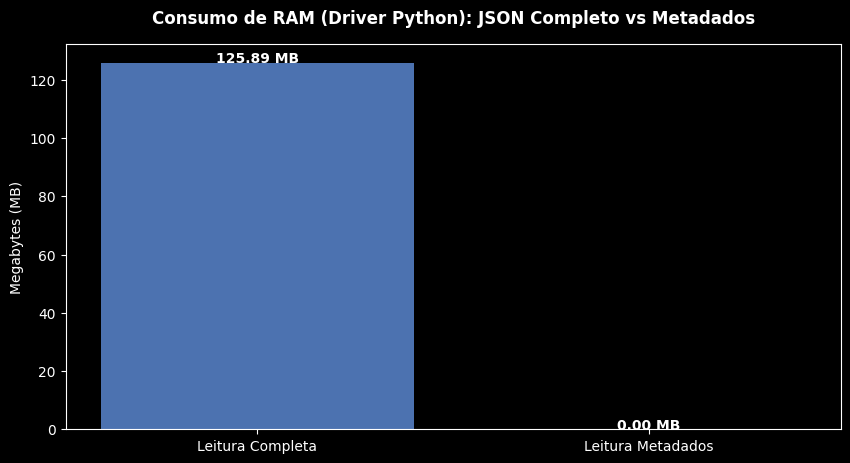

In [14]:
fig_ram_j, ax_ram_j = plt.subplots(figsize=(10, 5))
plt.style.use('dark_background')

labels_ram = ['Leitura Completa', 'Leitura Metadados']
valores_ram = [ram_json['read_full'], ram_json['read_meta']]

bars = ax_ram_j.bar(labels_ram, valores_ram, color=['#4C72B0', '#C44E52'])
ax_ram_j.set_title('Consumo de RAM (Driver Python): JSON Completo vs Metadados', fontweight='bold', pad=15)
ax_ram_j.set_ylabel('Megabytes (MB)')

for bar in bars:
    yval = bar.get_height()
    ax_ram_j.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f} MB', ha='center', fontweight='bold')

plt.show()

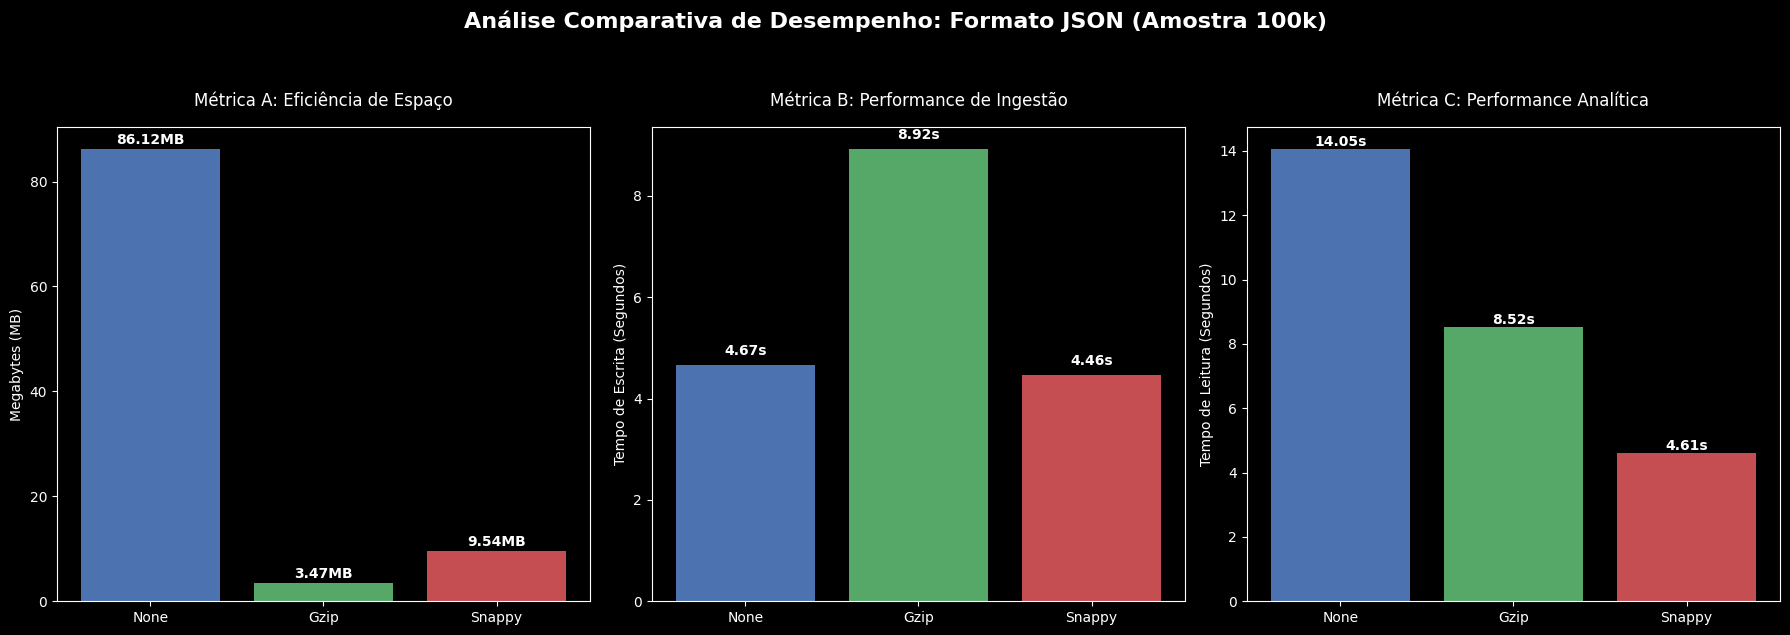

In [15]:
import matplotlib.pyplot as plt

compressoes = ['None', 'Gzip', 'Snappy']

%matplotlib inline
plt.style.use('dark_background')
cores = ['#4C72B0', '#55A868', '#C44E52'] # Azul, Verde, Vermelho

tamanhos_mb = [86.12, 3.47, 9.54]          # Tamanho em MB para None, Gzip, Snappy
tempos_escrita = [4.6712, 8.9193, 4.4626]  # Tempo de Escrita em segundos
tempos_leitura = [14.0477, 8.5179, 4.6120] # Tempo de Leitura (Completa, Parcial, Metadados) para Snappy

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análise Comparativa de Desempenho: Formato JSON (Amostra 100k)', fontsize=16, fontweight='bold', y=1.05)

# --- GRÁFICO 1: TAMANHO EM DISCO ---
bars1 = ax1.bar(compressoes, tamanhos_mb, color=cores)
ax1.set_title('Métrica A: Eficiência de Espaço', fontsize=12, pad=15)
ax1.set_ylabel('Megabytes (MB)')
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}MB', ha='center', fontweight='bold')

# --- GRÁFICO 2: TEMPO DE ESCRITA ---
bars2 = ax2.bar(compressoes, tempos_escrita, color=cores)
ax2.set_title('Métrica B: Performance de Ingestão', fontsize=12, pad=15)
ax2.set_ylabel('Tempo de Escrita (Segundos)')
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{yval:.2f}s', ha='center', fontweight='bold')

# --- GRÁFICO 3: TEMPO DE LEITURA ---
bars3 = ax3.bar(compressoes, tempos_leitura, color=cores)
ax3.set_title('Métrica C: Performance Analítica', fontsize=12, pad=15)
ax3.set_ylabel('Tempo de Leitura (Segundos)')
for bar in bars3:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

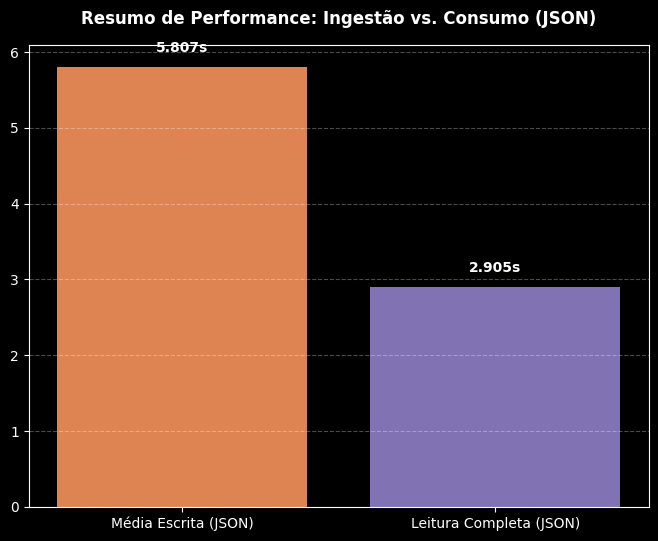

In [17]:
fig_traf_j, ax_traf_j = plt.subplots(figsize=(8, 6))

media_escrita_j = (4.33 + 8.78 + 4.31) / 3 
valores_traf = [media_escrita_j, tempos_json['read_full']]
labels_traf = ['Média Escrita (JSON)', 'Leitura Completa (JSON)']

bars = ax_traf_j.bar(labels_traf, valores_traf, color=['#DD8452', '#8172B3'])
ax_traf_j.set_title('Resumo de Performance: Ingestão vs. Consumo (JSON)', fontweight='bold', pad=15)
ax_traf_j.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    ax_traf_j.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{yval:.3f}s', ha='center', fontweight='bold')

plt.show()

# 1.5 Metodologia e Considerações Técnicas (JSON)
- Nota Metodológica: Diagnóstico de Codecs
Diferente do formato XML, a implementação do JSON foi realizada de forma 100% nativa no Apache Spark. Isso eliminou os erros de dependências externas, mas revelou uma limitação de infraestrutura local: a ausência do codec zstd nas bibliotecas nativas do Hadoop/Spark do ambiente de teste.

Para manter a precisão do estudo, o benchmark focou nos compressores Gzip (foco em armazenamento) e Snappy (foco em performance), utilizando a amostragem padrão de 100.000 registros para garantir a paridade comparativa com os formatos anteriores.

- O Papel da Inteligência Artificial (AI-Driven Engineering)
Nesta etapa final, a Inteligência Artificial (Gemini) atuou como Analista de Sistemas, auxiliando na interpretação dos erros de IllegalStateException e validando os dados de leitura analítica. A colaboração permitiu identificar que, no JSON, a leitura de metadados (.schema) é significativamente mais rápida que a leitura parcial, um comportamento típico de formatos que exigem o escaneamento do arquivo para inferência de tipos.

- Referências Bibliográficas
ECMA International: Standard ECMA-404 - The JSON Data Interchange Syntax.

JSON.org: Documentação Oficial do Formato.

Apache Spark Documentation: JSON Files - Spark SQL, DataFrames and Datasets Guide.

CROCKFORD, Douglas: How JavaScript Works. (Referência sobre a evolução e eficiência do JSON).